Virtual Acoustics and Immersive Audio Workshop - CCRMA Stanford University  
29.07.25 - Orchisama Das, Gloria Dal Santo
  
### L07: Ambisonics-encoded RIRs

In this assignment we will 
- Convert A-format FOA recordings to B-format.
- Visualise spherical harmomic basis functions.
- Save B-format SRIRs in a SOFA file for multiple listener positions.
- Listen to auralization with saved SRIRs either binaurally or out-loud in the 22.1 setup in CCRMA's studio E.

In [1]:
import sys
from pathlib import Path

# 把 src 的絕對路徑加進去
sys.path.append(str((Path().resolve() / ".." / "src").resolve()))
print(sys.path)  # ← 應該會看到有一個 .../VAIAWorkshop25Public/src


['c:\\Users\\HP\\VAIAWorkshop25Public\\notebooks', 'c:\\Users\\HP\\anaconda3\\python312.zip', 'c:\\Users\\HP\\anaconda3\\DLLs', 'c:\\Users\\HP\\anaconda3\\Lib', 'c:\\Users\\HP\\anaconda3', '', 'c:\\Users\\HP\\anaconda3\\Lib\\site-packages', 'c:\\Users\\HP\\anaconda3\\Lib\\site-packages\\win32', 'c:\\Users\\HP\\anaconda3\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\HP\\anaconda3\\Lib\\site-packages\\Pythonwin', 'C:\\Users\\HP\\VAIAWorkshop25Public\\src']


In [2]:
from utils import rir_from_sweep, find_onset, ms_to_samps

In [3]:
import numpy as np
import soundfile as sf
import sofar

from pathlib import Path
import matplotlib.pyplot as plt
from loguru import logger
from utils import rir_from_sweep, find_onset, ms_to_samps
from spatial_audio.spatial import convert_A2B_format_tetramic
from spatial_audio.plot import plot_spherical_harmonics
from spatial_audio.sofa_parser import SRIRWriter

### Part 1
- Complete the multichannel deconvolution function `utils.rir_from_sweep()`
- Given the sine sweeps measured in the racquetball court at receiver locations, A,D,G,H,J,K for source location I, C, B and the dry sweep, deconvolve them to get A-format RIRs. The measured RIRs are in the GDrive folder `Assignments/Data/Week 2/shoe-box-synth-comp/ambi_rec/`. 

2025-07-29 16:28:45.819 | INFO     | __main__:<module>:12 - Calculating RIRs for source position I


2025-07-29 16:28:46.207 | INFO     | __main__:<module>:19 - Done calculating RIRs for receiver position A
2025-07-29 16:28:46.774 | INFO     | __main__:<module>:19 - Done calculating RIRs for receiver position D
2025-07-29 16:28:47.355 | INFO     | __main__:<module>:19 - Done calculating RIRs for receiver position G
2025-07-29 16:28:47.975 | INFO     | __main__:<module>:19 - Done calculating RIRs for receiver position H
2025-07-29 16:28:48.518 | INFO     | __main__:<module>:19 - Done calculating RIRs for receiver position K
2025-07-29 16:28:48.689 | INFO     | __main__:<module>:12 - Calculating RIRs for source position C
2025-07-29 16:28:49.067 | INFO     | __main__:<module>:19 - Done calculating RIRs for receiver position A
2025-07-29 16:28:49.602 | INFO     | __main__:<module>:19 - Done calculating RIRs for receiver position D
2025-07-29 16:28:50.148 | INFO     | __main__:<module>:19 - Done calculating RIRs for receiver position G
2025-07-29 16:28:50.689 | INFO     | __main__:<module

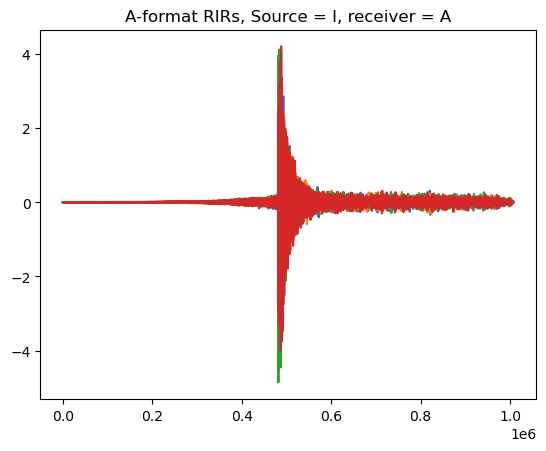

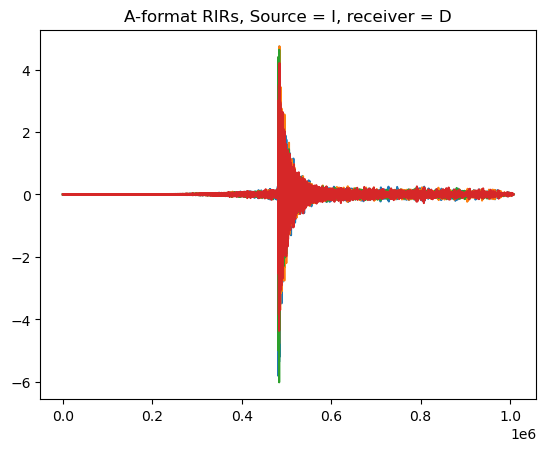

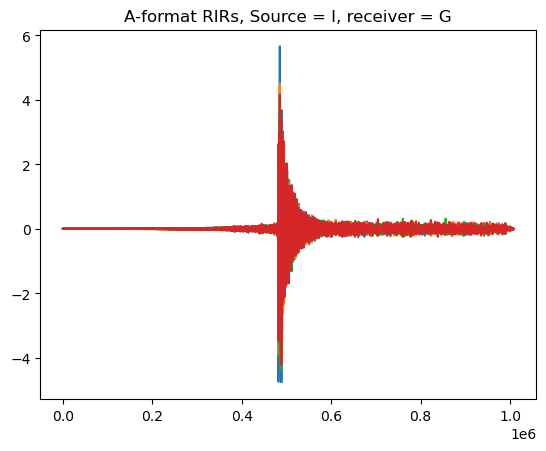

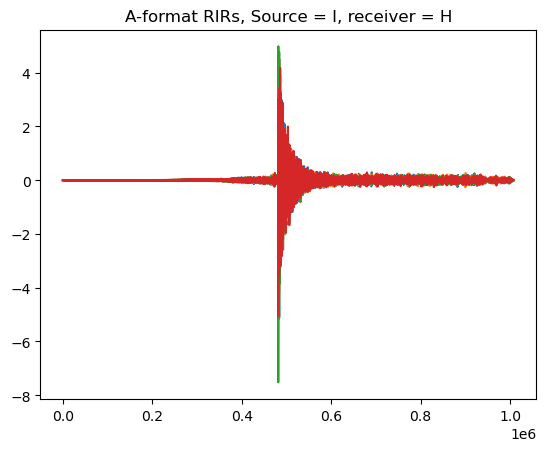

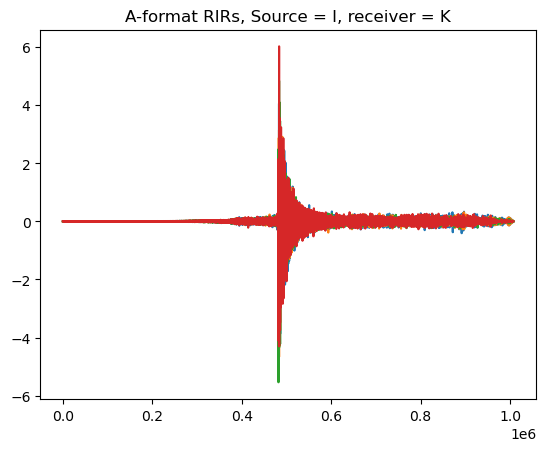

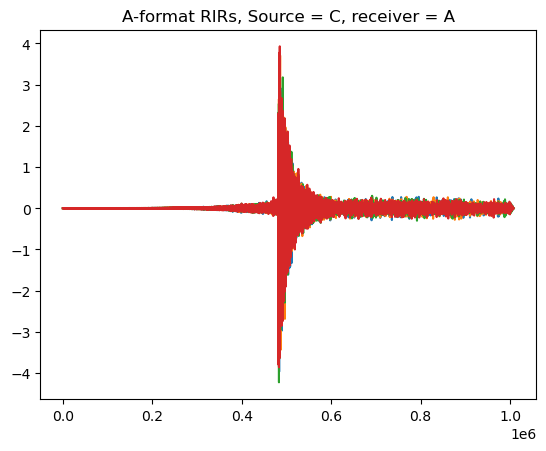

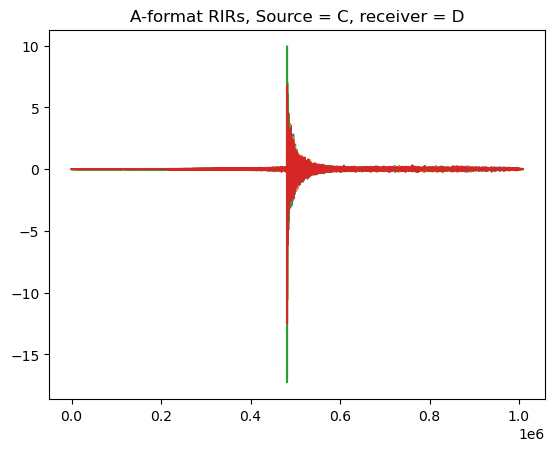

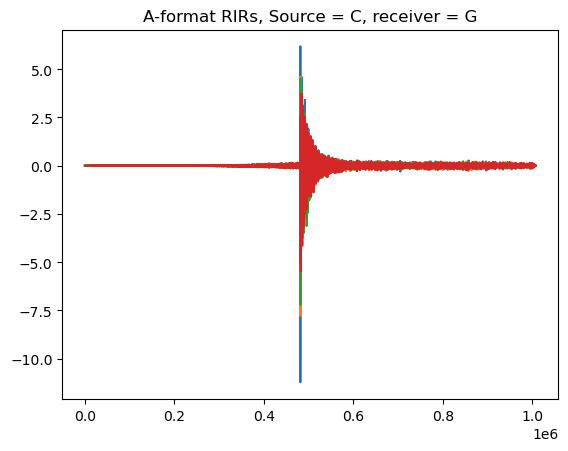

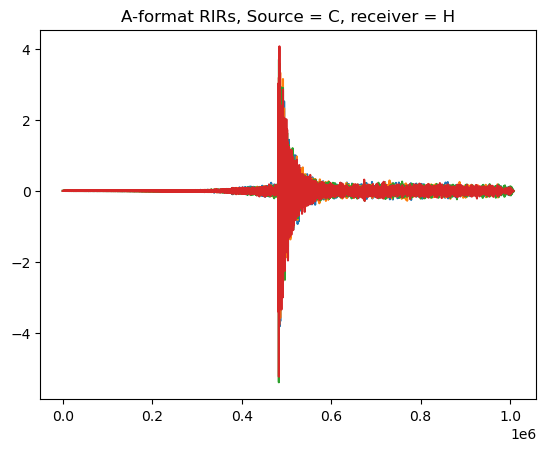

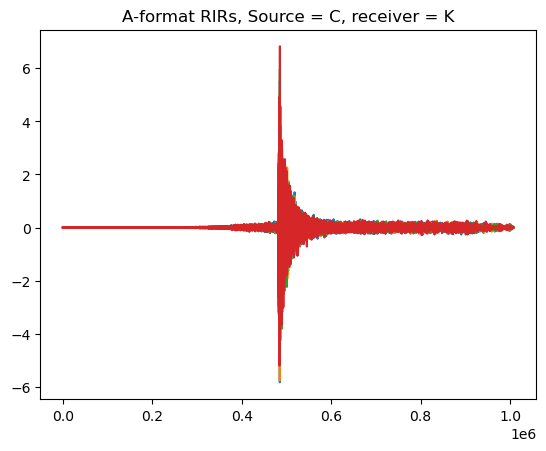

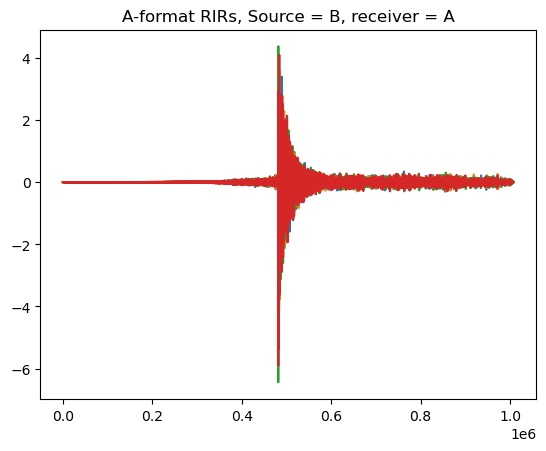

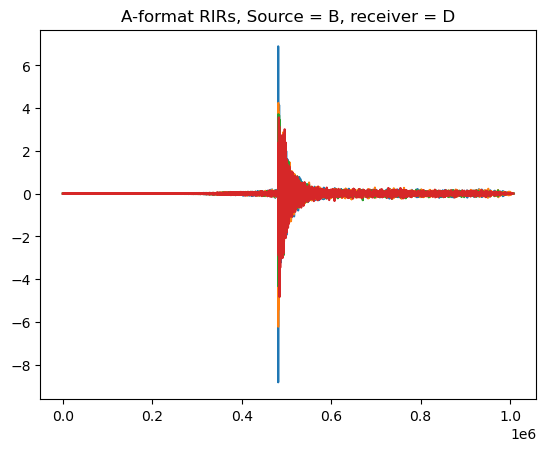

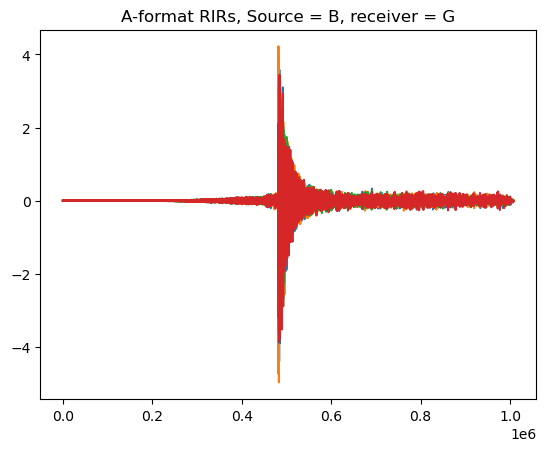

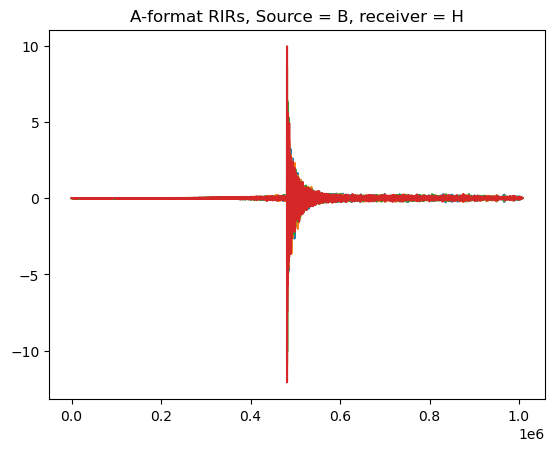

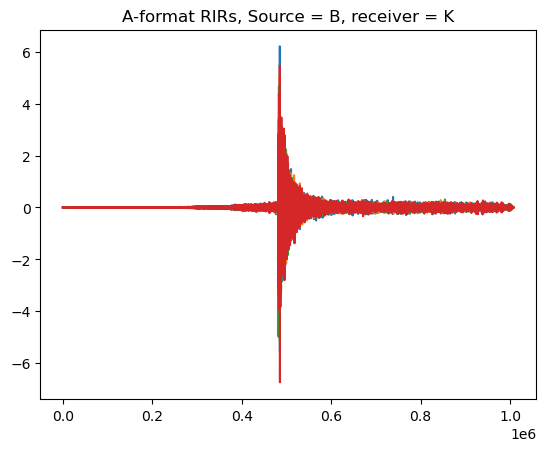

In [4]:
# Read DrySweep
audio_path = Path('../data/Week 2/shoe-box-synth-comp/ambi_rec').resolve()
dry_sweep, fs = sf.read(f'{audio_path}/DrySweep.wav')

# Define source and receiver names
src_name = ['I', 'C', 'B']
rec_name = ['A','D','G','H','K']

# Loop through source and receivers to get all the RIRs
rirs_Aformat = {}
for k in range(len(src_name)):
    logger.info(f"Calculating RIRs for source position {src_name[k]}")
    for i in range(len(rec_name)):
        # Read measured sweeps
        meas_sweep, fs = sf.read(f'{audio_path}/Speaker_src={src_name[k]}_rec={rec_name[i]}.wav')
        
        # Call rir_from_sweep to get A-format RIRs for current receiver and source
        rirs_Aformat[src_name[k]+rec_name[i]] = rir_from_sweep(meas_sweep, dry_sweep, fs)
        logger.info(f"Done calculating RIRs for receiver position {rec_name[i]}")
        
        # Plot the A format RIRs for current source and listener positions
        plt.figure()
        plt.plot(rirs_Aformat[src_name[k]+rec_name[i]])
        plt.title(f'A-format RIRs, Source = {src_name[k]}, receiver = {rec_name[i]}')

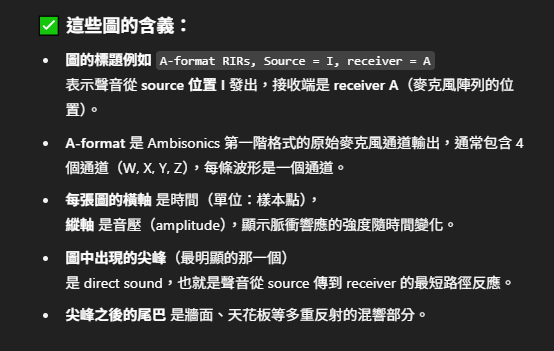
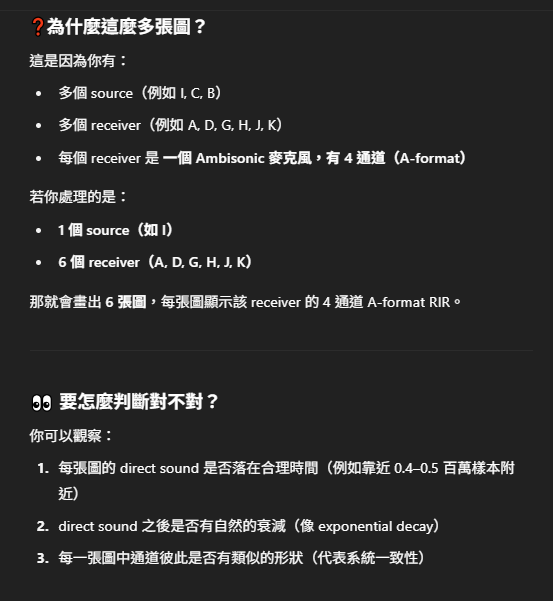

### Part 2

- Convert the A-format recordings to B-format using SN3D normalization and ACN channel ordering by completing the function `convert_A2B_format_tetramic()` in `spatial_audio.spatial.py`.
- Recall that we want to convert from A-format RIRs, $\mathbf{d}(t) = \begin{bmatrix}d_1(t) & d_2(t) & d_3(t) & d_4(t) \end{bmatrix}^\top$ to B-format RIRs, $\mathbf{h}(t) = \begin{bmatrix}W(t) & Y(t) & Z(t) & X(t) \end{bmatrix}^\top$, using the spherical harmonics transformation matrix $\mathbf{Y}$. The pseudo-inverse of $\mathbf{Y}$ is given by $\mathbf{Y}^\dagger$.
\begin{equation}
    \begin{aligned}
    \mathbf{h}(t) &= \mathbf{Y}^\dagger \mathbf{d}(t) \\
    \mathbf{Y} &= \begin{bmatrix}Y_{0,0}(\boldsymbol{\theta, \phi}) & Y_{1,-1}(\boldsymbol{\theta, \phi}) & Y_{1,0}(\boldsymbol{\theta, \phi}) & Y_{1,1}(\boldsymbol{\theta, \phi}) \end{bmatrix}, \\
    Y_{0,0}(\boldsymbol{\theta, \phi}) & =\frac{1}{\sqrt{4 \pi}} \\
    Y_{1,-1}(\boldsymbol{\theta, \phi}) & =\sqrt{\frac{3}{4 \pi}} \sin \boldsymbol{\theta} \sin \boldsymbol{\phi} \\
    Y_{1,0}(\boldsymbol{\theta, \phi}) & =\sqrt{\frac{3}{4 \pi}} \cos \boldsymbol{\theta} \\
    Y_{1,1}(\boldsymbol{\theta, \phi}) & =\sqrt{\frac{3}{4 \pi}} \sin \boldsymbol{\theta} \cos \boldsymbol{\phi} \\
    \boldsymbol{\theta}, \boldsymbol{\phi} &\in \mathbb{R}^4, \ \theta_i = \arccos(z_i), \ \phi_i = \arctan(y_i, x_i) \\
    \mathbf{e}_i &= \frac{1}{\sqrt{3}}\begin{bmatrix} x_i & y_i & z_i\end{bmatrix}^\top.
    \end{aligned}
    \end{equation}
    Here, $\mathbf{e}_i$ contains the direction vectors for each of the four capsules of the tetramic (this has been provided in the code). Hint: the calculations can be greatly simplified if you calculate $\theta_i, \phi_i$ from $\mathbf{e}_i$ and plug it in $\mathbf{Y}$.

[DEBUG] Converting A2B, input shape = (1007999, 4)


2025-07-29 16:29:12.670 | INFO     | __main__:<module>:12 - Done calculating RIRs for receiver position A


[DEBUG] Converting A2B, input shape = (1007999, 4)


2025-07-29 16:29:13.628 | INFO     | __main__:<module>:12 - Done calculating RIRs for receiver position D


[DEBUG] Converting A2B, input shape = (1007999, 4)


...

2025-07-29 16:29:23.852 | INFO     | __main__:<module>:12 - Done calculating RIRs for receiver position G


[DEBUG] Converting A2B, input shape = (1007999, 4)


2025-07-29 16:29:24.725 | INFO     | __main__:<module>:12 - Done calculating RIRs for receiver position H


[DEBUG] Converting A2B, input shape = (1007999, 4)


2025-07-29 16:29:25.644 | INFO     | __main__:<module>:12 - Done calculating RIRs for receiver position K


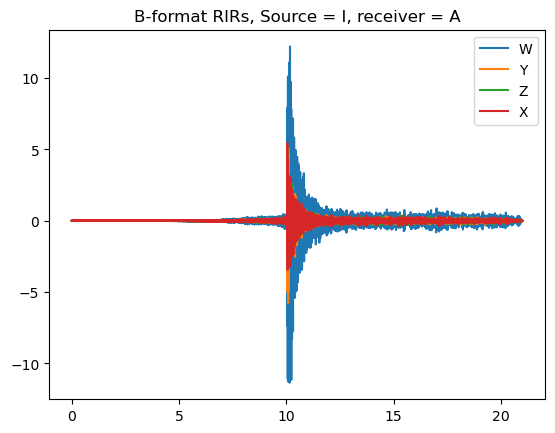

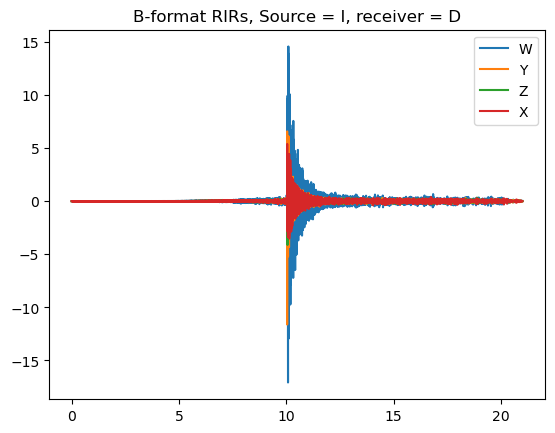

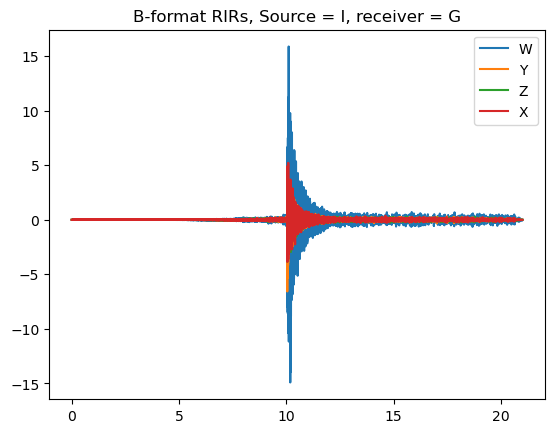

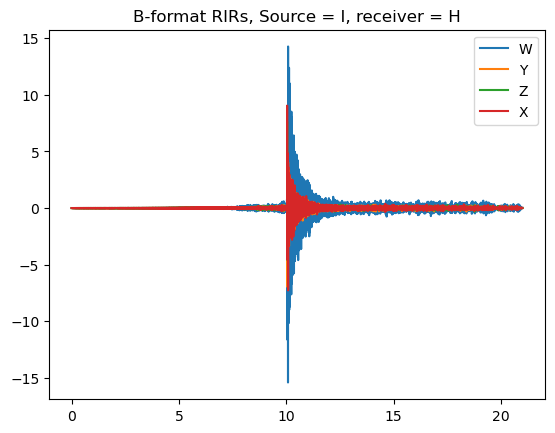

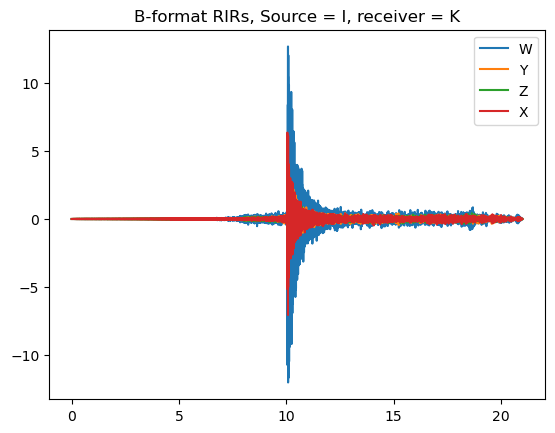

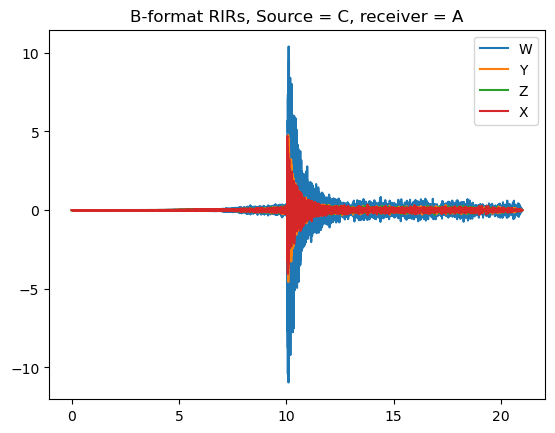

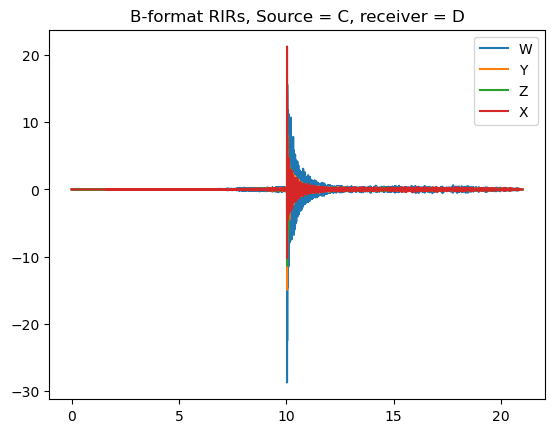

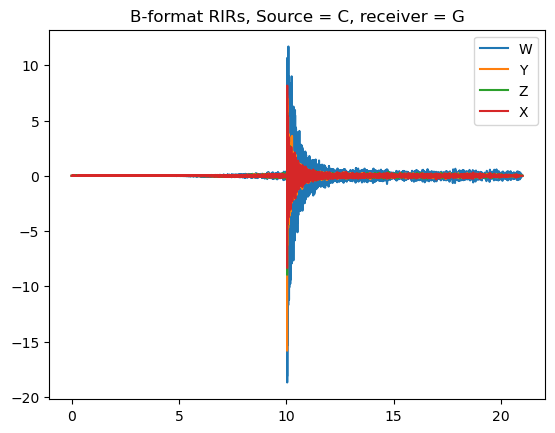

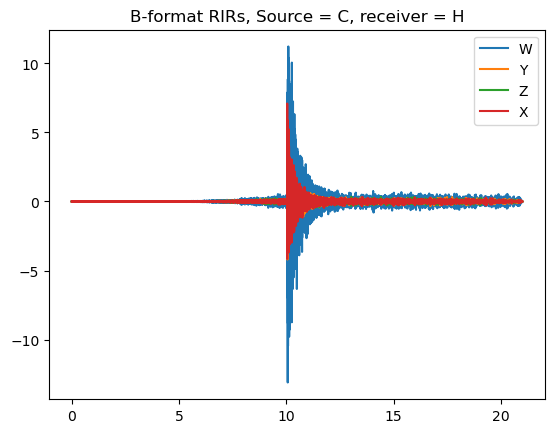

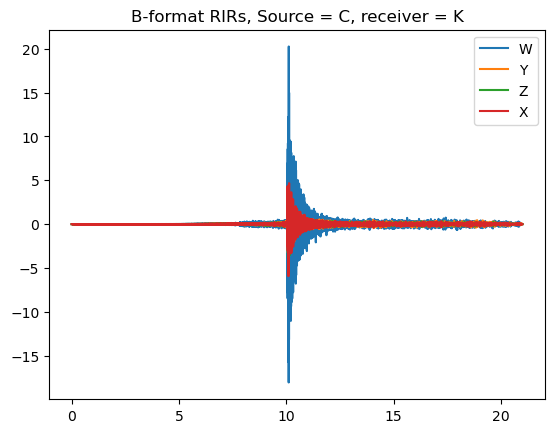

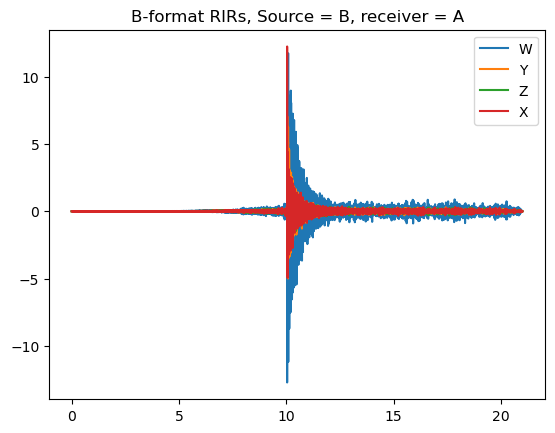

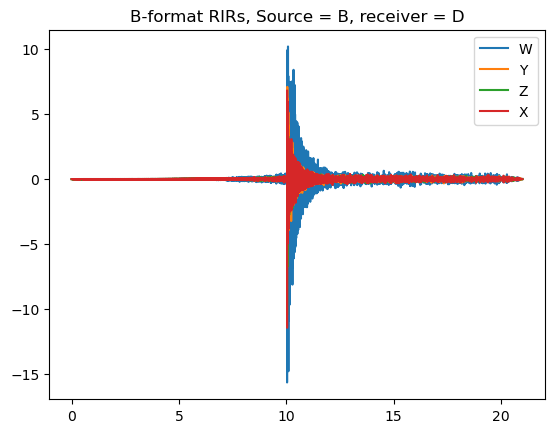

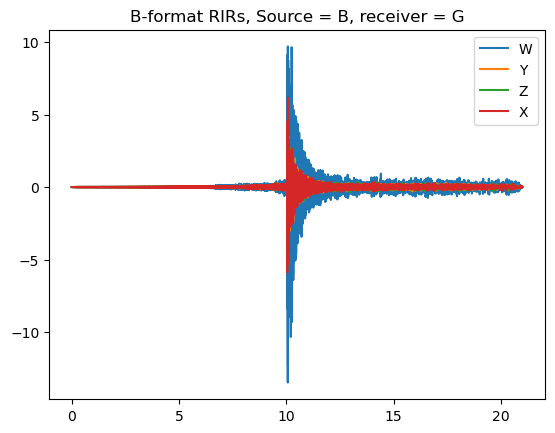

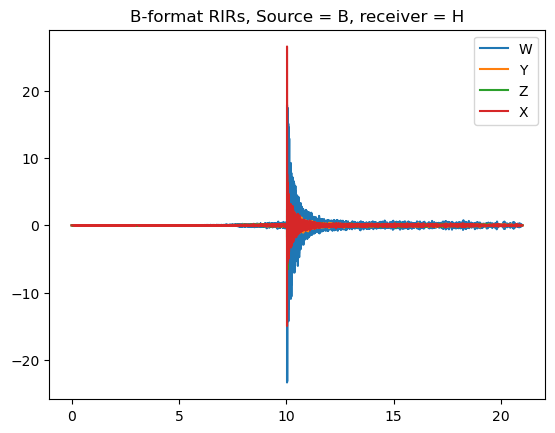

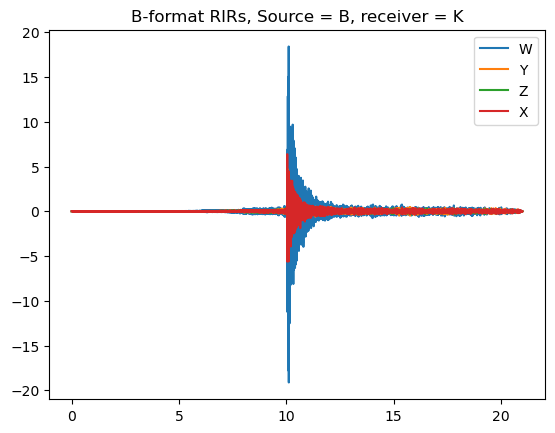

In [5]:
rirs_Bformat = {}
rirs_onset = {}
time = np.linspace(0, (rirs_Aformat['CA'].shape[0]-1)/fs, rirs_Aformat['CA'].shape[0])

for k in range(len(src_name)):
    for i in range(len(rec_name)):
        # Get B-format RIRs by calling convert_A2B_format_from_tetramic()
        rirs_Bformat[src_name[k] + rec_name[i]] = convert_A2B_format_tetramic(rirs_Aformat[src_name[k] + rec_name[i]])
        
        # Get onsets for each RIR by calling find_onset
        rirs_onset[src_name[k] + rec_name[i]] = find_onset(rirs_Bformat[src_name[k] + rec_name[i]])
        logger.info(f"Done calculating RIRs for receiver position {rec_name[i]}")

        # Plot B-format RIRs for current source and listener positions
        plt.figure()
        plt.plot(time, rirs_Bformat[src_name[k] + rec_name[i]])
        plt.title(f'B-format RIRs, Source = {src_name[k]}, receiver = {rec_name[i]}')
        plt.legend(['W','Y','Z','X'])

In [6]:
for k in range(len(src_name)):
    for i in range(len(rec_name)):
        key = src_name[k] + rec_name[i]
        if key not in rirs_Aformat:
            print(f"[ERROR] Missing key in rirs_Aformat: {key}")
        else:
            print(f"[OK] Found key: {key}, shape: {rirs_Aformat[key].shape}")

[OK] Found key: IA, shape: (1007999, 4)
[OK] Found key: ID, shape: (1007999, 4)
[OK] Found key: IG, shape: (1007999, 4)
[OK] Found key: IH, shape: (1007999, 4)
[OK] Found key: IK, shape: (1007999, 4)
[OK] Found key: CA, shape: (1007999, 4)
[OK] Found key: CD, shape: (1007999, 4)
[OK] Found key: CG, shape: (1007999, 4)
[OK] Found key: CH, shape: (1007999, 4)
[OK] Found key: CK, shape: (1007999, 4)
[OK] Found key: BA, shape: (1007999, 4)
[OK] Found key: BD, shape: (1007999, 4)
[OK] Found key: BG, shape: (1007999, 4)
[OK] Found key: BH, shape: (1007999, 4)
[OK] Found key: BK, shape: (1007999, 4)


Previous error
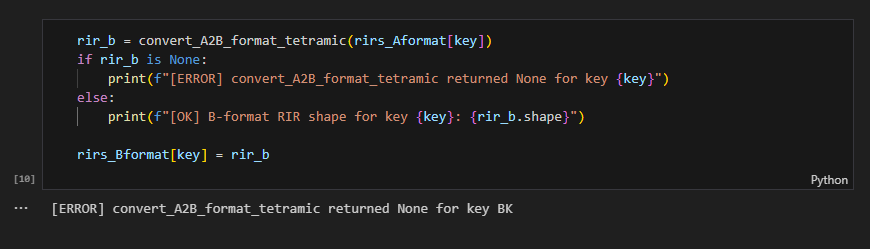

In [7]:
rir_b = convert_A2B_format_tetramic(rirs_Aformat[key])
if rir_b is None:
    print(f"[ERROR] convert_A2B_format_tetramic returned None for key {key}")
else:
    print(f"[OK] B-format RIR shape for key {key}: {rir_b.shape}")

rirs_Bformat[key] = rir_b

[DEBUG] Converting A2B, input shape = (1007999, 4)
[OK] B-format RIR shape for key BK: (1007999, 4)


### Part 3

Using `spatial_audio.plot.plot_spherical_harmonics`, visualise spherical harmonic functions up to order 3.

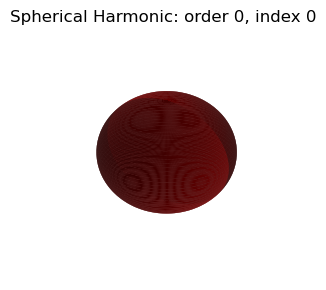

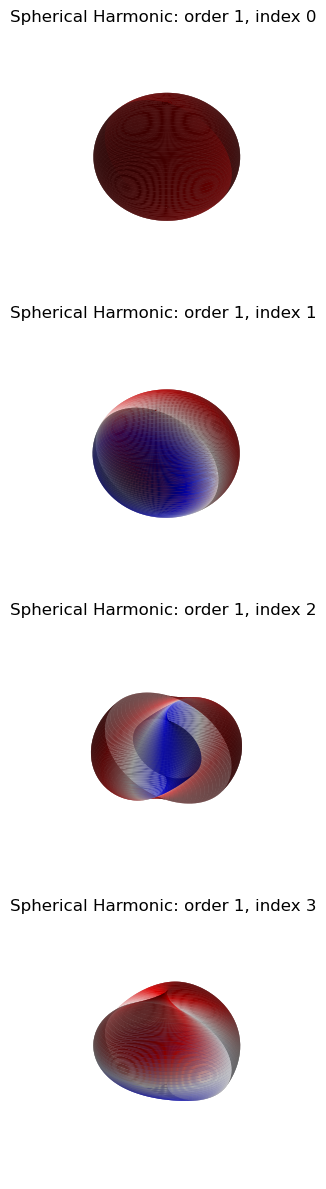

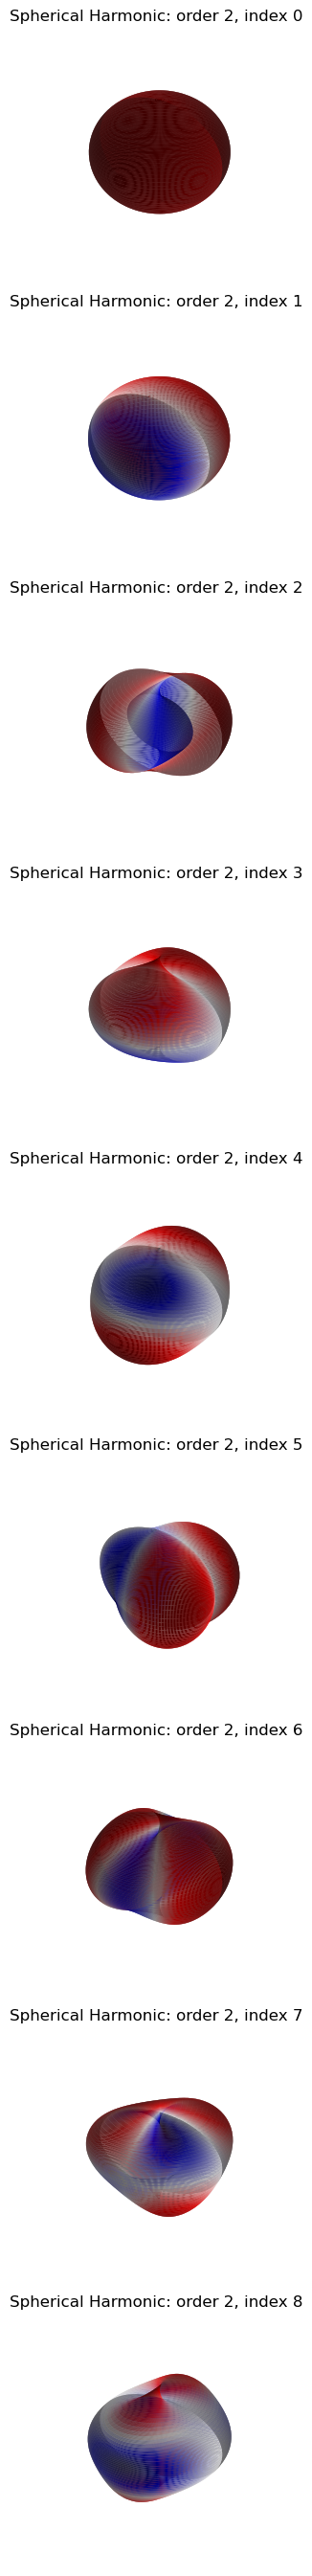

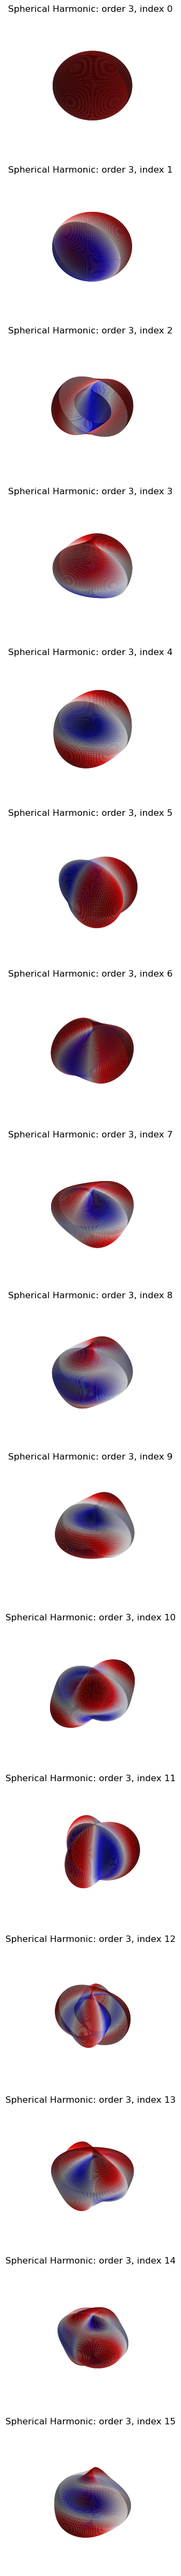

In [8]:
### WRITE YOUR CODE HERE ###
from spatial_audio.plot import plot_spherical_harmonics

# 可視化實數球面諧波（Real Spherical Harmonics）階數 0～3
# - 參數 orders_list = [0, 1, 2, 3]：代表你希望畫出 l = 0 到 l = 3 的所有 SH 函數
# - 這些圖有助於理解各階 SH 在空間上的變化樣貌，應用於 Ambisonics 編碼與方向性聲音分析
plot_spherical_harmonics(orders_list=[0, 1, 2, 3])

### Part 4
Save the B-format recordings as wav files with the convention `Bformat_Speaker_src={src_pos_name}_rec={rec_pos_name}.wav`. The files can be saved in the folder `../data/Week 2/shoe-box-synth-comp/ambi_rec/`.

In [9]:
# Trim the RIRs to be 10s long and normalize them to be within +/- 1
start_trim_len_samps = ms_to_samps(10000, fs)
end_trim_len_samps = ms_to_samps(5000, fs)
rirs_Bformat_array = np.stack(list(rirs_Bformat.values()))
rirs_Bformat_array = rirs_Bformat_array[:,start_trim_len_samps:-end_trim_len_samps, :]
norm_factor = np.max(np.abs(rirs_Bformat_array), axis=1, keepdims=True)
rirs_Bformat_norm = rirs_Bformat_array / norm_factor

### WRITE YOUR CODE HERE ###

# Save wave files

import soundfile as sf
import os

# 建立輸出資料夾（如果尚未存在的話）
out_dir = './data/Week 2/shoe-box-synth-comp/ambi_rec/'
os.makedirs(out_dir, exist_ok=True)

# 對每一組 B-format RIR 執行儲存動作
for i, key in enumerate(rirs_Bformat.keys()):
    # 取得對應的 B-format impulse response
    rir = rirs_Bformat_norm[i]  # shape: (samples, 4)，對應 W, Y, Z, X 四通道

    # 拆解出來源與接收器的代碼（例如 key = ('I', 'A')）
    src, rec = key

    # 根據指定格式命名檔案，例如 Bformat_Speaker_src=I_rec=A.wav
    filename = f"Bformat_Speaker_src={src}_rec={rec}.wav"

    # 合併成完整儲存路徑
    out_path = os.path.join(out_dir, filename)

    # 儲存為 32-bit float WAV（Ambisonics 常見格式）
    sf.write(out_path, rir, samplerate=fs)

    # 印出確認訊息（可選）
    print(f"Saved: {out_path}")


Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=I_rec=A.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=I_rec=D.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=I_rec=G.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=I_rec=H.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=I_rec=K.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=C_rec=A.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=C_rec=D.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=C_rec=G.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=C_rec=H.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=C_rec=K.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=B_rec=A.wav
Saved: ./data/Week 2/shoe-box-synth-comp/ambi_rec/Bformat_Speaker_src=B_rec=D.wav
Saved: ./data/We

### Part 5
Save the B-format normalized SRIRs for each source in a different SOFA file of convention `SingleRoomSRIR` file using the `SRIRWriter` class.

In [20]:
# Length of the RIRs we are saving in SOFA format
ir_length = rirs_Bformat['CA'].shape[0] - end_trim_len_samps - start_trim_len_samps

# SH order
ambi_order = 1

# Sampling rate
sample_rate = fs

# Create source and receiver position arrays
src_pos = np.asarray([[5.3, 6.7, 1.5], [3.048, 9.14, 1.5], [3.048, 6.1, 1.5]])
rec_pos = np.asarray([[1.524, 3.05, 1.5], [2.032, 8.13, 1.5], [1, 10.5, 1.5], [2.7, 4.5, 1.5], [3.048, 1, 1.5]])

# Number of receivers
num_rec = rec_pos.shape[0]

# Room dimensions (optional)
room_dims = np.array([6.096, 12.19, 6.096])

# ensure B-format RIR array has the right dimensions - (number of measurements, number of channels, length of RIRs)
rirs_Bformat_norm = rirs_Bformat_norm.transpose(0, -1, 1)
rirs_onset_array = np.stack(list(rirs_onset.values()))

In [21]:
import time

In [22]:
print("📦 src_name:", src_name if 'src_name' in locals() else "❌ Not defined")
print("📦 src_pos shape:", src_pos.shape if 'src_pos' in locals() else "❌ Not defined")
print("📦 rec_pos shape:", rec_pos.shape if 'rec_pos' in locals() else "❌ Not defined")


print("📦 rirs_Bformat_norm shape:", rirs_Bformat_norm.shape if 'rirs_Bformat_norm' in locals() else "❌ Not defined")
print("📦 rirs_onset_array shape:", rirs_onset_array.shape if 'rirs_onset_array' in locals() else "❌ Not defined")

print("📦 sample_rate:", sample_rate if 'sample_rate' in locals() else "❌ Not defined")
print("📦 ir_length:", ir_length if 'ir_length' in locals() else "❌ Not defined")
print("📦 room_dims:", room_dims if 'room_dims' in locals() else "❌ Not defined")


📦 src_name: ['I', 'C', 'B']
📦 src_pos shape: (3, 3)
📦 rec_pos shape: (5, 3)
📦 rirs_Bformat_norm shape: (15, 287999, 4)
📦 rirs_onset_array shape: (15, 4)
📦 sample_rate: 48000
📦 ir_length: 287999
📦 room_dims: [ 6.096 12.19   6.096]


In [23]:
print(rirs_Bformat_norm.shape)

(15, 287999, 4)


In [34]:
import time  # required by SRIRWriter internal use
# 只做一次 reshape
rirs_Bformat_norm_reshaped = rirs_Bformat_norm.reshape(len(src_name), rec_pos.shape[0], -1, rirs_Bformat_norm.shape[2])
for i in range(len(src_name)):
    sofa_path = Path(f'../data/Week 2/shoe-box-synth-comp/sofa_files/racquetball_src={src_name[i]}_srirs.sofa').resolve()

    srir_writer = SRIRWriter(
        num_receivers=rec_pos.shape[0],        # 4
        num_channels=rirs_Bformat_norm.shape[2],  # 4
        ir_length=ir_length,
        samplerate=sample_rate,
        room_dims=room_dims
    )

    src_pos_all = np.tile(src_pos[i], (rec_pos.shape[0], 1))  # (4, 3)
    srir_writer.set_source_positions(src_pos_all)
    srir_writer.set_listener_positions(rec_pos)

    # reshape: (287999, 4, 4) → (4, 4, 287999)
    rir_data = rirs_Bformat_norm[i].transpose(0, 2, 1)  # 正確順序：receiver, channel, time
    print("rir_data.shape:", rir_data.shape)  # (4, 4, 287999)
    srir_writer.set_ir_data(rir_data)

    # onset: (4, 4)
    onset_data = rirs_onset_array[i]
    print("onset_data.shape:", onset_data.shape)
    srir_writer.set_ir_delays(onset_data)

    srir_writer.write_to_file(str(sofa_path))
    print(f"✅ Saved: {sofa_path}")

ValueError: axes don't match array

In [35]:
    print("rir_data.shape:", rir_data.shape)

rir_data.shape: (1, 4, 287999)


In [36]:
print("rirs_Bformat_norm.shape =", rirs_Bformat_norm.shape)
print("src_name =", src_name)

rirs_Bformat_norm.shape = (15, 287999, 4)
src_name = ['I', 'C', 'B']


In [38]:
import time  # required by SRIRWriter internal use

# 先 reshape 完整的資料（外面做一次即可）
rirs_reshaped = rirs_Bformat_norm.reshape(len(src_name), rec_pos.shape[0], -1, 4)  # → (3, 5, 287999, 4)
onset_reshaped = rirs_onset_array.reshape(len(src_name), rec_pos.shape[0], 4)     # → (3, 5, 4)

for i in range(len(src_name)):
    # current sofa path
    sofa_path = Path(f'../data/Week 2/shoe-box-synth-comp/sofa_files/racquetball_src={src_name[i]}_srirs.sofa').resolve()

    # create SRIRWriter object
    srir_writer = SRIRWriter(
        num_receivers=rec_pos.shape[0],
        num_channels=rirs_Bformat_norm.shape[2],  # 通常是 4
        ir_length=ir_length,
        samplerate=sample_rate,
        room_dims=room_dims
    )

    # set source positions
    src_pos_all = np.tile(src_pos[i], (rec_pos.shape[0], 1))  # (5, 3)
    srir_writer.set_source_positions(src_pos_all)

    # set listener positions
    srir_writer.set_listener_positions(rec_pos)  # (5, 3)

    # set impulse response data: (5, 287999, 4) → (5, 4, 287999)
    rir_data = rirs_reshaped[i].transpose(0, 2, 1)
    print("rir_data.shape:", rir_data.shape)
    srir_writer.set_ir_data(rir_data)

    # set onset delays
    onset_data = onset_reshaped[i]  # shape: (5, 4)
    print("onset_data.shape:", onset_data.shape)
    srir_writer.set_ir_delays(onset_data)

    # save sofa to file
    sofa_path.parent.mkdir(parents=True, exist_ok=True)
    srir_writer.write_to_file(str(sofa_path))
    print(f"✅ Saved: {sofa_path}")

rir_data.shape: (5, 4, 287999)
onset_data.shape: (5, 4)
✅ Saved: C:\Users\HP\VAIAWorkshop25Public\Data\Week 2\shoe-box-synth-comp\sofa_files\racquetball_src=I_srirs.sofa
rir_data.shape: (5, 4, 287999)
onset_data.shape: (5, 4)
✅ Saved: C:\Users\HP\VAIAWorkshop25Public\Data\Week 2\shoe-box-synth-comp\sofa_files\racquetball_src=C_srirs.sofa
rir_data.shape: (5, 4, 287999)
onset_data.shape: (5, 4)
✅ Saved: C:\Users\HP\VAIAWorkshop25Public\Data\Week 2\shoe-box-synth-comp\sofa_files\racquetball_src=B_srirs.sofa


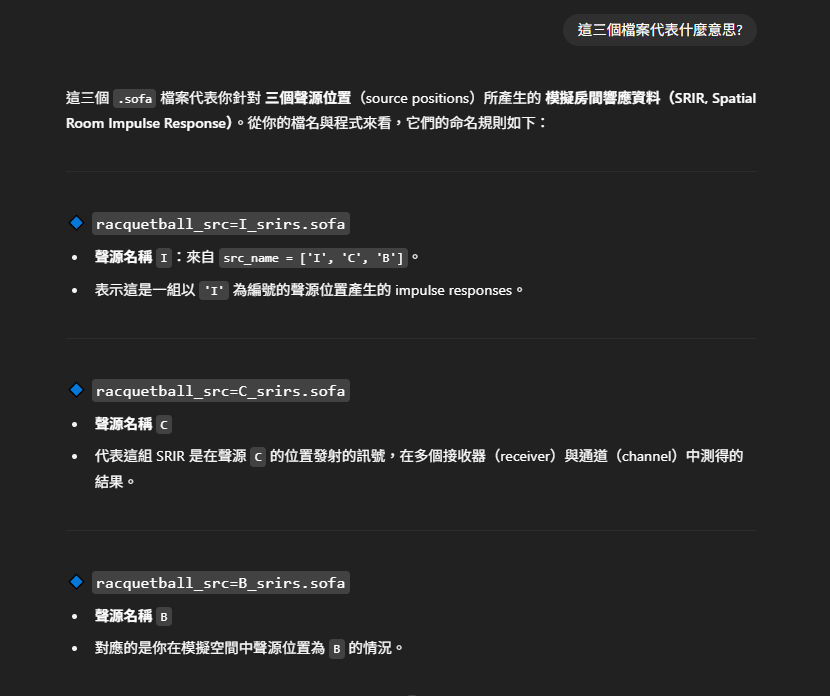
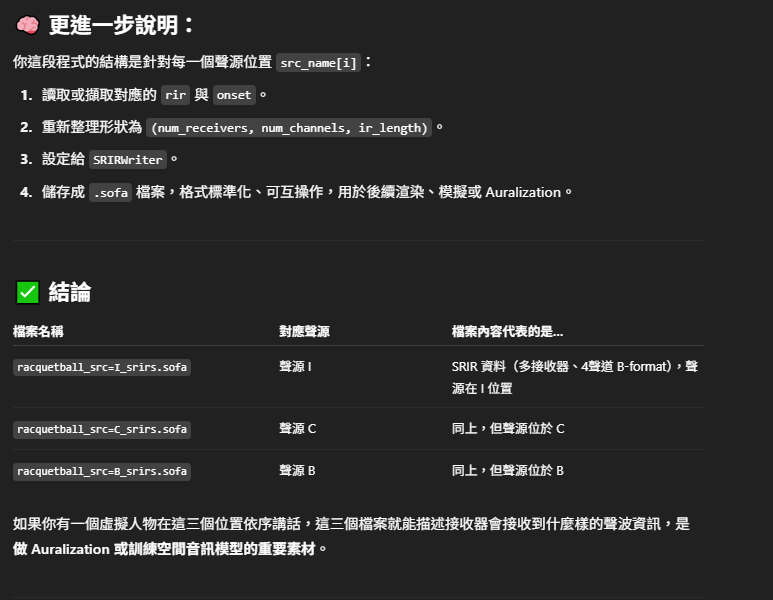

In [39]:
print("rir_data.shape:", rir_data.shape)
print("onset_data.shape:", onset_data.shape)

rir_data.shape: (5, 4, 287999)
onset_data.shape: (5, 4)


In [29]:
print(f"🧪 Writing SOFA for source {src_name[i]}...")
print(" - rir_data.shape:", rir_data.shape)
print(" - onset.shape:", rirs_onset_array[i].shape)

🧪 Writing SOFA for source I...
 - rir_data.shape: (1, 4, 287999)
 - onset.shape: (4,)


In [ ]:
### WRITE YOUR CODE HERE ###

for i in range(len(src_name)):
    # current sofa path
    sofa_path = Path(f'../data/Week 2/shoe-box-synth-comp/sofa_files/racquetball_src={src_name[i]}_srirs.sofa').resolve()

    # create SRIRWriter object
    
    # set source positions
    
    # set listener positions
    
    # set impulse response data
    
    # optional - set onset delays
    
    # save sofa to file
        

In [ ]:
# OPTIONAL - Read SOFA file to ensure everything was saved properly

sofa_reader = sofar.read_sofa(sofa_path)
sofa_reader.list_dimensions